# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from astropy.table import Table, vstack
from scipy.optimize import curve_fit
from rapidfuzz import fuzz

# Set Paths

In [3]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

# Functions

In [4]:
def normalize_name(name):

    s = name.strip()
    if s.endswith('.0'):
        s = s[:-2]
    # collapse repeated spaces
    s = ' '.join(s.split())
    return s.upper()

def names_match(a, b, fuzzy_threshold=90):

    na, nb = normalize_name(a), normalize_name(b)
    if na == nb:
        return True
    # fallback fuzzy match on normalized forms
    score = fuzz.ratio(na, nb)
    return score >= fuzzy_threshold

def find_matches(list1, list2, fuzzy_threshold=90):
    
    matches = []
    for a in list1:
        for b in list2:
            if names_match(a, b, fuzzy_threshold=fuzzy_threshold):
                matches.append((a, b))
    return matches

def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog


def line(x_data,m,c): 
    return m*x_data + c 

# Catalogs

In [5]:
MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazar_Catalog_v2.fits')

In [6]:
Matched_Blazar_Fit_All = Table.read(outdir + 'Blazar_Fitter_out/Matched_Blazar_Fits_All/MeV_Blazar_Fits_All_results.fits')
#Matched_Blazar_Fit_All.pprint_all()

In [7]:
Fermi_Bright_Blazars = Table.read(catalog_dir + 'Fermi_Bright_Blazars.fits')
#Fermi_Bright_Blazars.pprint_all()

In [8]:
Fermi_AGN_Cat_lo = Table.read(catalog_dir + "table-4LAC-DR3-l.fits")
Fermi_AGN_Cat_hi = Table.read(catalog_dir + "table-4LAC-DR3-h.fits")
Fermi_LAC_DR3 = vstack([Fermi_AGN_Cat_lo, Fermi_AGN_Cat_hi])

In [9]:
Fermi_LAT_4FGL_DR4_catalog = Table.read(catalog_dir + "4FGLDR4.fit", hdu=1) 

# Code

In [10]:
Fermi_Bright_Blazars.pprint_all()

   LAT Name         Counterpart Name(s)          R.A.       Decl.      Z   Radio Flux V_mag X-ray Flux alpha_ro alpha_ox alpha_rx alpha_xgamma SED (Available) alpha_r log(nu^S_peak) log(nu^S_peak F(nu^S_peak)) log(nu^IC_peak) log(nu^IC_peak F(nu^IC_peak)) log(gamma^SSC_peak) Compton SED (Classification)   Optical   
-------------- ------------------------------ ---------- ----------- ----- ---------- ----- ---------- -------- -------- -------- ------------ --------------- ------- -------------- --------------------------- --------------- ----------------------------- ------------------- ------- -------------------- ------------
J0017.4 - 0503 1RXS J001736.1-0/BZQJ0017-0512 00 17 35.8 -05 12 41.6 0.227        274  18.2   8.03e-13     0.59     1.28     0.83         0.57             ...   0.127         -/13.6                     -/-11.4          -/20.7                           ...                 3.4     ...                  LSP         FSRQ
J0033.6 - 1921 1RXS J003334.6-1/BZBJ0033-1921 

In [11]:
Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU = mask_catalog_by_class(Matched_Blazar_Fit_All, 'Class')
Matched_Blazar_Fit_Catalogs_by_class = [Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU]

In [12]:
MeV_Blazar_Catalog_FSRQ, MeV_Blazar_Catalog_BLL, MeV_Blazar_Catalog_BCU = mask_catalog_by_class(MeV_Blazar_Catalog, 'Fermi Type')
MeV_Blazar_Catalog_Catalogs_by_class = [MeV_Blazar_Catalog_FSRQ, MeV_Blazar_Catalog_BLL, MeV_Blazar_Catalog_BCU]

[-2.96748479  8.3358545 ]


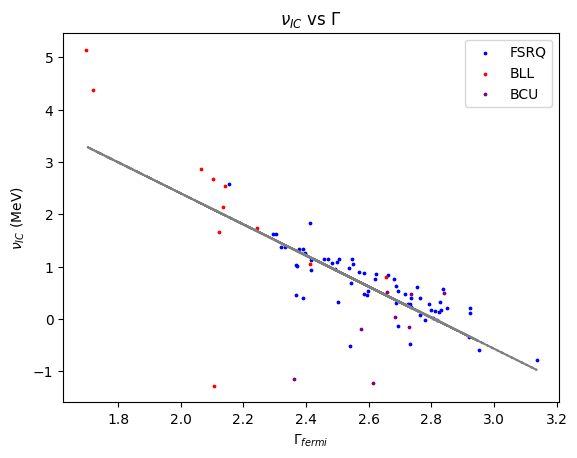

In [13]:
labels = ['FSRQ', 'BLL', 'BCU']
colors = ['blue', 'red', 'purple']

source_photon_index_all = []
IC_peak_all = []

for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):

    IC_peak_energies = Matched_Blazar_Fit_Catalogs_by_class[i]['IC_Peak_Energy'].tolist()
    source_photon_index_by_class = []
    IC_peak_by_class = []

    for x in range(len(IC_peak_energies)):

        if IC_peak_energies[x] != 'None':
            if np.log10(float(IC_peak_energies[x])) >= -2:
                source_photon_index = MeV_Blazar_Catalog_Catalogs_by_class[i]['Fermi Photon Index'].tolist()[x]
                source_photon_index_by_class.append(float(source_photon_index))
                IC_peak_by_class.append(np.log10(float(IC_peak_energies[x])))

    source_photon_index_all.append(source_photon_index_by_class)
    IC_peak_all.append(IC_peak_by_class)

for i in range(len(source_photon_index_all)):
    plt.scatter(source_photon_index_all[i], IC_peak_all[i], s=3, color=colors[i], label=labels[i])

fermi_photon_index_all_vals = np.array(source_photon_index_all[0] + source_photon_index_all[1] + source_photon_index_all[2])
IC_peak_all_vals = np.array(IC_peak_all[0] + IC_peak_all[1] + IC_peak_all[2])


popt,pcov = curve_fit(line,fermi_photon_index_all_vals,IC_peak_all_vals, p0=[2,4])
print(popt)

all_fit_slope = popt[0]
all_fit_intercept = popt[1]

plt.plot(fermi_photon_index_all_vals, line(fermi_photon_index_all_vals,*popt), color = 'grey', linestyle = '--')
plt.xlabel(r'$\Gamma_{fermi}$')
plt.ylabel(r'$\nu_{IC}$ (MeV)')
plt.title(r'$\nu_{IC}$ vs $\Gamma$')
plt.legend()
plt.savefig(outdir + 'gamma_IC_line_fit_all.png')
plt.show()
plt.close()

In [14]:
FBB_counterpart_names = Fermi_Bright_Blazars['Counterpart Name(s)'].tolist()
print(FBB_counterpart_names)

FBB_counterpart_names_split = [item.split('/') for item in FBB_counterpart_names]
print(FBB_counterpart_names_split)
print(len(FBB_counterpart_names_split))

BZ_cat_names = []
Counterpart_names = []

for i in FBB_counterpart_names_split:
    if len(i) == 1:
        if i[0].startswith('BZ'):
            BZ_cat_names.append(i[0])
            Counterpart_names.append('None')
        else:
            BZ_cat_names.append('None')
            Counterpart_names.append(i[0])
    elif len(i) == 2:
        BZ_cat_names.append(i[1])
        Counterpart_names.append(i[0])
    
print(BZ_cat_names)
print(len(BZ_cat_names))
print(Counterpart_names)
print(len(Counterpart_names))

['1RXS J001736.1-0/BZQJ0017-0512', '1RXS J003334.6-1/BZBJ0033-1921', 'PKS0048-09/BZBJ0050-0929', 'PKS0048-71/BZQJ0051-0650', 'GB6J0100+0745', 'GC 0109+224/BZBJ0112+2244', 'PKS 0116-219/BZQJ0118-2141', '1Jy0118-272/BZBJ0120-2701', '1RXS J013632.9+3/BZBJ0136+3905', 'S40133+47/BZQJ0136+4751', 'CLASSJ0144+2705', 'PKS 0142-278/BZQJ0145-2733', 'PKS 0202-17/BZQJ0204-1701', 'PKS0208-512/BZUJ0210-5101', 'PKS 0215+015/BZQJ0217+0144', '1Jy0218+357/BZUJ0221+3556', '3C 66A/BZBJ0222+4302', 'PKS0227-369/BZQJ0229-3643', '4C28.07/BZQJ0237+2848', 'PKS0235+164/BZBJ0238+1636', 'PKS0244-470', 'PKS 0301-243/BZBJ0303-2407', 'PKS0332-403/BZBJ0334-4008', 'PKS 0347-211/BZQJ0349-2102', 'PKS0405-385/BZUJ0406-3826', 'SUMSSJ041313-533', 'PKS0420-01/BZQJ0423-0120', 'PKS0426-380/BZBJ0428-3756', 'PKS0447-439/BZBJ0449-4350', 'PKS0454-234/BZQJ0457-2324', '1ES0502+675/BZBJ0507+6737', 'MC4 0516-621/BZUJ0516-6207', 'PKS 0528+134/BZQJ0530+1331', 'PKS0537-441/BZBJ0538-4405', 'GB6J0654+5042', 'S4 0650+45/BZUJ0654+4514', 'PKS0

In [15]:
FBB_counterpart_names = Fermi_Bright_Blazars['Counterpart Name(s)'].tolist()
print(FBB_counterpart_names)

FBB_counterpart_names_split = [item.split('/') for item in FBB_counterpart_names]
print(FBB_counterpart_names_split)
print(len(FBB_counterpart_names_split))

BZ_cat_names = []
Counterpart_names = []

for i in FBB_counterpart_names_split:
    if len(i) == 1:
        if i[0].startswith('BZ'):
            BZ_cat_names.append(i[0])
            Counterpart_names.append('None')
        else:
            BZ_cat_names.append('None')
            Counterpart_names.append(i[0])
    elif len(i) == 2:
        BZ_cat_names.append(i[1])
        Counterpart_names.append(i[0])
    
print(BZ_cat_names)
print(len(BZ_cat_names))
print(Counterpart_names)
print(len(Counterpart_names))

['1RXS J001736.1-0/BZQJ0017-0512', '1RXS J003334.6-1/BZBJ0033-1921', 'PKS0048-09/BZBJ0050-0929', 'PKS0048-71/BZQJ0051-0650', 'GB6J0100+0745', 'GC 0109+224/BZBJ0112+2244', 'PKS 0116-219/BZQJ0118-2141', '1Jy0118-272/BZBJ0120-2701', '1RXS J013632.9+3/BZBJ0136+3905', 'S40133+47/BZQJ0136+4751', 'CLASSJ0144+2705', 'PKS 0142-278/BZQJ0145-2733', 'PKS 0202-17/BZQJ0204-1701', 'PKS0208-512/BZUJ0210-5101', 'PKS 0215+015/BZQJ0217+0144', '1Jy0218+357/BZUJ0221+3556', '3C 66A/BZBJ0222+4302', 'PKS0227-369/BZQJ0229-3643', '4C28.07/BZQJ0237+2848', 'PKS0235+164/BZBJ0238+1636', 'PKS0244-470', 'PKS 0301-243/BZBJ0303-2407', 'PKS0332-403/BZBJ0334-4008', 'PKS 0347-211/BZQJ0349-2102', 'PKS0405-385/BZUJ0406-3826', 'SUMSSJ041313-533', 'PKS0420-01/BZQJ0423-0120', 'PKS0426-380/BZBJ0428-3756', 'PKS0447-439/BZBJ0449-4350', 'PKS0454-234/BZQJ0457-2324', '1ES0502+675/BZBJ0507+6737', 'MC4 0516-621/BZUJ0516-6207', 'PKS 0528+134/BZQJ0530+1331', 'PKS0537-441/BZBJ0538-4405', 'GB6J0654+5042', 'S4 0650+45/BZUJ0654+4514', 'PKS0

In [16]:
FBB_IC_peaks = Fermi_Bright_Blazars['log(nu^IC_peak)'].tolist()
print(FBB_IC_peaks)

FBB_IC_peaks_split = [item.split('/') for item in FBB_IC_peaks]
print(FBB_IC_peaks_split)

FBB_IC_peak_SED_fit = []
FBB_IC_peak_gamma_calc = []

for i in FBB_IC_peaks_split:
    if i[0] == '-':
        FBB_IC_peak_SED_fit.append('None')
    else:
        FBB_IC_peak_SED_fit.append(np.log10((10 ** float(i[0])) * 4.1357e-21))

    FBB_IC_peak_gamma_calc.append(np.log10((10 ** float(i[1]))  * 4.1357e-21))

print(FBB_IC_peak_SED_fit)
print(len(FBB_IC_peak_SED_fit))
print(FBB_IC_peak_gamma_calc)
print(len(FBB_IC_peak_gamma_calc))

['-/20.7', '24.3/24.8', '22.4/23', '-/22.7', '-/24.4', '-/23.1', '-/22.3', '-/23.6', '-/24.9', '22.6/22.8', '-/22.7', '-/21.4', '-/21.6', '22.4/22.4', '-/23', '-/21.1', '24.2/23.7', '21.8/21.3', '22.1/21.6', '23.2/23.3', '-/22.2', '-/23.5', '-/23', '21.8/21.3', '-/22.3', '-/22.4', '21.7/22', '22.8/23', '23.9/23.5', '22.8/22.6', '24.3/24.9', '22.5/22.9', '21.3/21.4', '22.7/22.8', '-/23.5', '-/22.3', '-/23.6', '23/23.4', '-/22.1', '-/22.1', '23.3/23.2', '22.6/22.5', '-/23.1', '-/23.3', '-/20.3', '21.4/22.3', '-/20.9', '22/22.2', '-/21.1', '-/23.5', '-/22.7', '24.5/24.6', '-/22.7', '-/21.6', '-/25.9', '-/22.6', '22.3/23.1', '22/22.7', '-/20.7', '25/24.5', '-/20.8', '-/22.7', '22/21.6', '-/24', '24/23.8', '21/20.7', '-/22.6', '22.1/23.8', '-/22.9', '22.2/22.1', '22.5/22.6', '-/21.2', '-/22', '-/22.1', '-/24.3', '22.7/22.6', '22.9/22.9', '-/21.9', '22.3/21.6', '-/23.8', '22.4/22', '23.5/23.5', '-/22.6', '-/24.7', '-/22', '-/21.7', '-/21.8', '-/21.8', '24.7/24.7', '24.7/24.2', '22.2/22.5', '

In [17]:
FBB_class = Fermi_Bright_Blazars['Optical'].tolist()
print(FBB_class)

FBB_Redshift = Fermi_Bright_Blazars['Z'].tolist()
FBB_Redshift = [float(i) if i != '...' else 'None' for i in FBB_Redshift]
print(FBB_Redshift)

FBB_IC_peak_flux = Fermi_Bright_Blazars['log(nu^IC_peak F(nu^IC_peak))'].tolist()
FBB_IC_peak_flux = [float(i) if i != '...' else 'None' for i in FBB_IC_peak_flux]
print(FBB_IC_peak_flux)

['FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'Unidentified', 'BL Lac', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'FSRQ', 'FSRQ', 'BL Lac', 'BZU', 'BL Lac', 'BL Lac', 'FSRQ', 'Unidentified', 'Unidentified', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'BL Lac', 'BZU', 'FSRQ', 'BL Lac', 'BZU', 'FSRQ', 'BZU', 'BL Lac', 'BZU', 'FSRQ', 'BL Lac', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'BL Lac', 'BZU', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'FSRQ', 'BL Lac', 'FSRQ', 'BL Lac', 'FSRQ', 'Unidentified', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'Unidentified', 'FSRQ', 'FSRQ', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ', 'BL Lac', 'BL Lac', 'FSRQ', 'FSRQ', 'FSRQ',

In [18]:
Bright_Blazars = Table([BZ_cat_names, Counterpart_names, FBB_class, FBB_IC_peak_SED_fit, FBB_IC_peak_flux, FBB_IC_peak_gamma_calc, FBB_Redshift], names = ['BZ Cat Name', 'Counterpart Name', 'Class', 'IC Peak SED Fit', 'IC Peak Flux SED Fit', 'IC Peak Gamma Calc', 'Redshift'])
Bright_Blazars.pprint_all()

 BZ Cat Name  Counterpart Name    Class      IC Peak SED Fit   IC Peak Flux SED Fit  IC Peak Gamma Calc Redshift
------------- ---------------- ------------ ------------------ -------------------- ------------------- --------
BZQJ0017-0512 1RXS J001736.1-0         FSRQ               None                 None 0.31654902789295575    0.227
BZBJ0033-1921 1RXS J003334.6-1       BL Lac  3.916549027892957                -11.1   4.416549027892957     0.61
BZBJ0050-0929       PKS0048-09       BL Lac  2.016549027892955                -10.6  2.6165490278929564     None
BZQJ0051-0650       PKS0048-71         FSRQ               None                 None  2.3165490278929557    1.975
         None    GB6J0100+0745 Unidentified               None                 None   4.016549027892955     None
BZBJ0112+2244      GC 0109+224       BL Lac               None                 None   2.716549027892958     None
BZQJ0118-2141     PKS 0116-219         FSRQ               None                 None  1.916549027

In [19]:
Bright_Blazars.write(catalog_dir + 'Bright_Blazars.fits', overwrite = True)
print(len(Bright_Blazars))

115


In [20]:
Bright_Blazars_SED_Fit_Mask = [x != 'None' for x in Bright_Blazars['IC Peak SED Fit']]
Masked_Bright_Blazars = Bright_Blazars[Bright_Blazars_SED_Fit_Mask]

FBB_fsrq_mask = [x in ['FSRQ'] for x in Masked_Bright_Blazars['Class'].tolist()]
FBB_bll_mask = [x in ['BL Lac'] for x in Masked_Bright_Blazars['Class'].tolist()]
FBB_bcu_mask = [x in ['BZU'] for x in Masked_Bright_Blazars['Class'].tolist()]

FBB_masked_catalog = [Masked_Bright_Blazars[FBB_fsrq_mask], Masked_Bright_Blazars[FBB_bll_mask], Masked_Bright_Blazars[FBB_bcu_mask]]

for i in range(len(FBB_masked_catalog)):
    IC_fit_peaks = [10 ** float(x) for x in FBB_masked_catalog[i]['IC Peak SED Fit'].tolist()]
    print(len(IC_fit_peaks), np.mean(IC_fit_peaks))

23 99.10879926872389
23 6713.030762950223
2 86.06965859579182


[('PKS 0142-278', 'PKS 0142-278'), ('PKS 0202-17', 'PKS 0202-17'), ('PKS0426-380', 'PKS 0426-380'), ('1ES0502+675', '1ES 0502+675'), ('PKS 0528+134', 'PKS 0528+134'), ('PKS0537-441', 'PKS 0537-441'), ('S50716+714', 'S5 0716+71'), ('MKN421', 'Mkn 421'), ('PKS1127-145', 'PKS 1127-14'), ('3C273', '3C 273'), ('3C279', '3C 279'), ('PKS 1329-049', 'PKS 1329-049'), ('PKS1510-08', 'PKS 1510-089'), ('PG 1553+113', 'PG 1553+113'), ('S51803+784', 'S5 1803+784'), ('1ES1959+650', '1ES 1959+650'), ('PKS2052-47', 'PKS 2052-47'), ('BLLAC', 'BL Lac'), ('PKS2227-08', 'PKS 2227-08'), ('3C454.3', '3C 454.3'), ('PKS2325+093', 'PKS 2325+093')]
21
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever
the best boyfriend ever


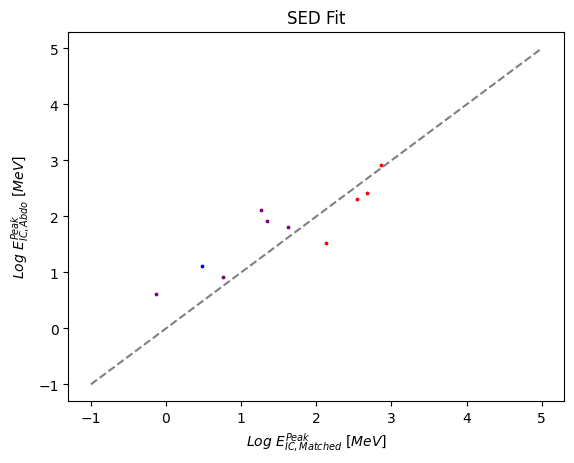

In [21]:
Bright_Blazar_Names = Bright_Blazars['Counterpart Name'].tolist()
Matched_cat_names = Matched_Blazar_Fit_All['Name'].tolist()

matched_names = find_matches(Bright_Blazar_Names, Matched_cat_names)
print(matched_names)
print(len(matched_names))
Bright_Blazar_names, Matched_Blazar_names = list(zip(*matched_names))
Matched_Bright_blazars, Matched_Matched_blazars = zip(*matched_names)

bright_blazar_match_mask = [x in Matched_Bright_blazars for x in Bright_Blazar_Names]
bright_blazars_matched = Bright_Blazars[bright_blazar_match_mask]

Matched_blazar_match_mask = [x in Matched_Matched_blazars for x in Matched_cat_names]
matched_blazar_matched = Matched_Blazar_Fit_All[Matched_blazar_match_mask]

matched_blazar_matched_class = matched_blazar_matched['Class'].tolist()

for i in range(len(Matched_Bright_blazars)):
    bright_blazars_matched_IC_peaks = bright_blazars_matched[bright_blazars_matched['Counterpart Name'] == Matched_Bright_blazars[i]]['IC Peak SED Fit'].tolist()[0]
    matched_blazar_matched_IC_peaks = matched_blazar_matched[matched_blazar_matched['Name'] == Matched_Matched_blazars[i]]['IC_Peak_Energy'].tolist()[0]
    matched_blazar_matched_class = matched_blazar_matched[matched_blazar_matched['Name'] == Matched_Matched_blazars[i]]['Class'].tolist()[0]

    if matched_blazar_matched_IC_peaks != 'None' and bright_blazars_matched_IC_peaks != 'None':
        dante_is_so_hot ='the best boyfriend ever'
        print(dante_is_so_hot)

        if matched_blazar_matched_class == 'bll' or matched_blazar_matched_class == 'BLL':
            color = 'red'
        elif matched_blazar_matched_class == 'fsrq' or matched_blazar_matched_class == 'fsrq':
            color = 'blue' 
        else:
            color = 'purple'

        plt.scatter(np.log10(float(matched_blazar_matched_IC_peaks)), float(bright_blazars_matched_IC_peaks), s = 3, color = color)
        plt.xlabel(r'$Log$ $E^{Peak}_{IC, Matched}$ $[MeV]$')
        plt.ylabel(r'$Log$ $E^{Peak}_{IC, Abdo}$ $[MeV]$')
        plt.title('SED Fit')

x = np.linspace(-1, 5, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'Compare_with_Abdo_2010_fits.png', bbox_inches='tight')

21
BL Lac PKS0426-380
0.26456671660368114
FSRQ PKS 0528+134
0.15494247406321027
BL Lac PKS0537-441
0.22340623177184993
BL Lac S50716+714
0.05797762137828277
FSRQ 3C273
0.7481237244134741
FSRQ 3C279
0.19152288748634128
FSRQ PKS1510-08
0.5760580434605846
BL Lac BLLAC
0.6142120983962673
FSRQ 3C454.3
0.8464446070364466
FSRQ PKS2325+093
0.6369046076734768


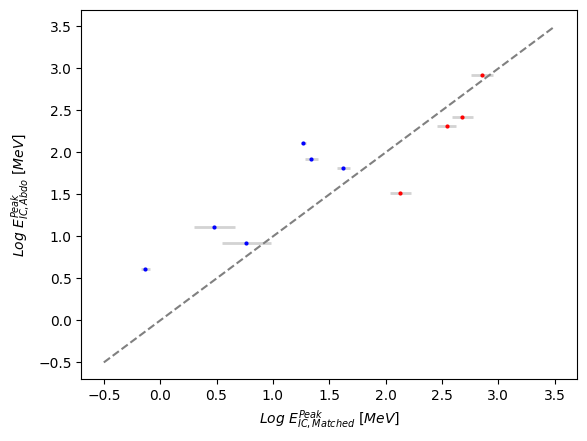

In [22]:
print(len(Bright_Blazar_names))

for i in range(len(Bright_Blazar_names)):
    
    mask = (Bright_Blazar_names[i] == Bright_Blazars['Counterpart Name'])
    if any(mask):
        LBAS_Peak_Energy = Bright_Blazars[mask]['IC Peak SED Fit'].tolist()[0]
        Class = Bright_Blazars[mask]['Class'].tolist()[0]
        
        #print(LBAS_Peak_Energy)
    mask2 = (Matched_Blazar_names[i] == Matched_Blazar_Fit_All['Name'])
    if any(mask2):
        Matched_Peak_Energy = Matched_Blazar_Fit_All[mask2]['IC_Peak_Energy'].tolist()[0]
        Matched_Peak_Energy_err = Matched_Blazar_Fit_All[mask2]['IC_Peak_Energy_Err'].tolist()[0]
        
    
    if LBAS_Peak_Energy != 'None' and Matched_Peak_Energy != 'None':
        print(Class, Bright_Blazar_names[i])
        if Class == 'FSRQ' or Class == 'fsrq':
            color = 'blue'
        elif Class == 'BL Lac' or Class == 'bll':
            color = 'red'
        else:
            color = 'purple'
        LBAS_Peak_Energy = float(LBAS_Peak_Energy)
        Matched_Peaked_Energy_log = np.log10(float(Matched_Peak_Energy))
        Matched_Peaked_Energy_err_log = (1 / (float(Matched_Peak_Energy) * np.log(10))) * float(Matched_Peak_Energy_err)
        print(abs(LBAS_Peak_Energy - Matched_Peaked_Energy_log))
        
        plt.errorbar(Matched_Peaked_Energy_log, LBAS_Peak_Energy, xerr=Matched_Peaked_Energy_err_log, fmt='o', markersize=2, color=color, ecolor='lightgray', elinewidth=2, capsize=0)
        plt.xlabel(r'$Log$ $E^{Peak}_{IC, Matched}$ $[MeV]$')
        plt.ylabel(r'$Log$ $E^{Peak}_{IC, Abdo}$ $[MeV]$')
        
plt.plot(np.linspace(-0.5, 3.5, 100), np.linspace(-0.5, 3.5, 100), linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'Compare_with_Abdo_2010_fits_with_errors.png', bbox_inches='tight')


('PKS 0142-278', 'PKS 0202-17', 'PKS0426-380', '1ES0502+675', 'PKS 0528+134', 'PKS0537-441', 'S50716+714', 'MKN421', 'PKS1127-145', '3C273', '3C279', 'PKS 1329-049', 'PKS1510-08', 'PG 1553+113', 'S51803+784', '1ES1959+650', 'PKS2052-47', 'BLLAC', 'PKS2227-08', '3C454.3', 'PKS2325+093')
('PKS 0142-278', 'PKS 0202-17', 'PKS 0426-380', '1ES 0502+675', 'PKS 0528+134', 'PKS 0537-441', 'S5 0716+71', 'Mkn 421', 'PKS 1127-14', '3C 273', '3C 279', 'PKS 1329-049', 'PKS 1510-089', 'PG 1553+113', 'S5 1803+784', '1ES 1959+650', 'PKS 2052-47', 'BL Lac', 'PKS 2227-08', '3C 454.3', 'PKS 2325+093')


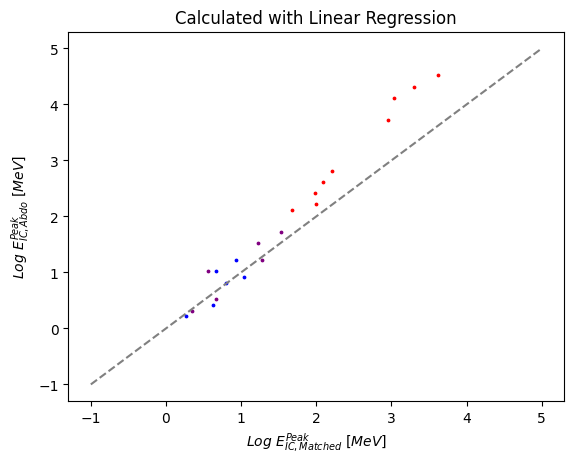

In [23]:
print(Matched_Bright_blazars)
print(Matched_Matched_blazars)

for i in range(len(Matched_Bright_blazars)):
    Abdo_Epeak = float(bright_blazars_matched[bright_blazars_matched['Counterpart Name'] == Matched_Bright_blazars[i]]['IC Peak Gamma Calc'].tolist()[0])
    LAT_gamma = Fermi_LAT_4FGL_DR4_catalog[Fermi_LAT_4FGL_DR4_catalog['ASSOC1'] == Matched_Matched_blazars[i].ljust(28)]['PL_Index'].tolist()[0]
    Calc_Epeak = all_fit_slope * LAT_gamma + all_fit_intercept
    Class = Fermi_LAC_DR3[Fermi_LAC_DR3['ASSOC1'] == Matched_Matched_blazars[i]]['CLASS'].tolist()[0]

    if Class == 'bll' or Class == 'BLL':
            color = 'red'
    elif Class == 'fsrq' or Class == 'fsrq':
        color = 'blue' 
    else:
        color = 'purple'

    plt.scatter(Calc_Epeak, Abdo_Epeak, color = color, label = Class, s = 3)
    plt.xlabel(r'$Log$ $E^{Peak}_{IC, Matched}$ $[MeV]$')
    plt.ylabel(r'$Log$ $E^{Peak}_{IC, Abdo}$ $[MeV]$')
    plt.title('Calculated with Linear Regression')

x = np.linspace(-1, 5, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'Calc_IC_peak_comparison.png', bbox_inches='tight')
 
    

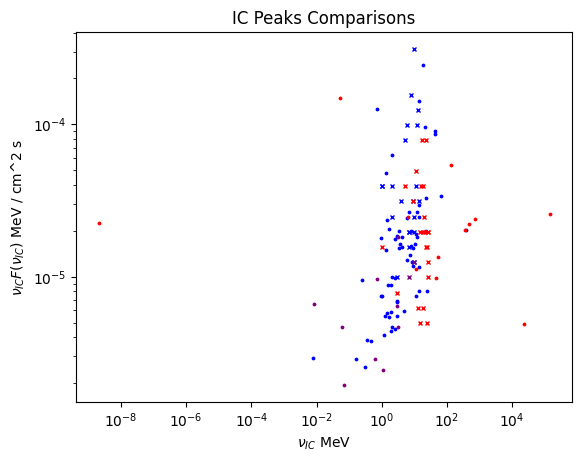

In [24]:
#plt.figure(figsize=(12,10))
for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):

    IC_peak_energies = Matched_Blazar_Fit_Catalogs_by_class[i]['IC_Peak_Energy'].tolist()
    E_peak_IC = []
    Flux_peak_IC = []

    for x in range(len(IC_peak_energies)):

        if IC_peak_energies[x] != 'None':
            #if np.log10(float(IC_peak_energies[x])) >= -2:
            IC_peak_flux = Matched_Blazar_Fit_Catalogs_by_class[i][x]['IC_Peak_Energy_Flux']
            E_peak_IC.append(float(IC_peak_energies[x]))
            Flux_peak_IC.append(float(IC_peak_flux))

    IC_peak_E_abdo = FBB_masked_catalog[i]['IC Peak SED Fit'].tolist()
    IC_peak_flux_abdo = FBB_masked_catalog[i]['IC Peak Flux SED Fit'].tolist()
    IC_peak_flux_abdo_MeV = [10 ** (float(x) + 5.795) for x in IC_peak_flux_abdo]

    #plt.figure(figsize=(8,6))
    plt.scatter(E_peak_IC, Flux_peak_IC, color = colors[i], label = labels[i], s = 3)
    plt.plot(IC_peak_E_abdo, IC_peak_flux_abdo_MeV, linestyle='None', markersize= 3, marker = 'x', color = colors[i])
    #plt.plot(IC_peak_E_LAC, IC_peak_flux_LAC, linestyle='None', markersize=3,marker='^',color=colors[i])
    plt.xscale('log')
    #plt.xlim(1e-3, 1e8)
    plt.yscale('log')
    plt.xlabel(r'$\nu_{IC}$ MeV')
    plt.ylabel(r'$\nu_{IC}F(\nu_{IC})$ MeV / cm^2 s')
    plt.title('IC Peaks Comparisons')
    #plt.savefig(outdir + 'All_study_IC_peaks_comp')
    plt.savefig(outdir + 'Abdo_and_Matched_Peaks.png')